In [1]:
# Required modules
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt 
import seaborn as sns 
import copy 
import time
import torch
import torch.nn as nn
from torch.optim import Adam
import torch.utils.data as Data 
from torchvision import transforms 
from torchvision.datasets import FashionMNIST
%matplotlib inline

ModuleNotFoundError: No module named 'pandas'

In [ ]:
# To decide whether to use GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0))

cuda
1
NVIDIA GeForce RTX 3060 Laptop GPU


In [ ]:
# FashionMNIST data，prepare traing dataset
train_data = FashionMNIST(
    root = './FashionMNIST',
    train = True,
    transform = transforms.ToTensor(),
    download = True
)

# Define a data loader
train_loader = Data.DataLoader(
    dataset = train_data,   # data
    batch_size = 64,    # batch size
    shuffle = False,   
    num_workers = 2,    
)

# batch No.
print(len(train_loader))

938


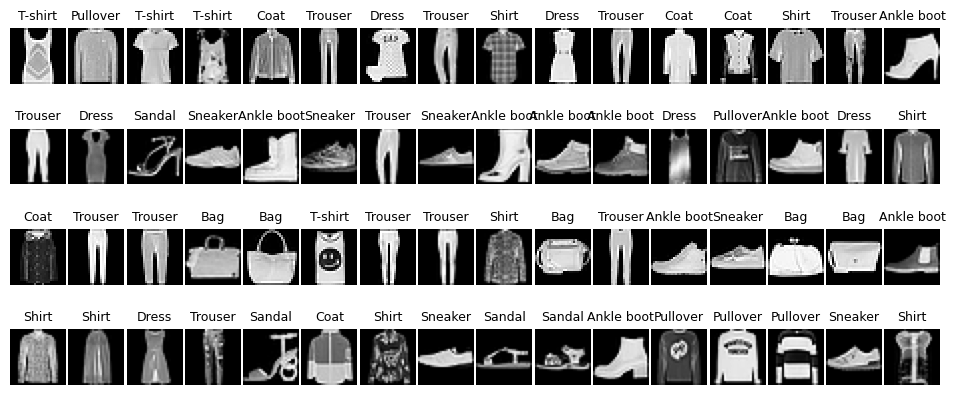

In [ ]:
# Obtain data for batches

for step, (b_x, b_y) in enumerate(train_loader):
    if step > 0:
        break

# Visualize images for a batch
batch_x = b_x.squeeze().numpy()
batch_y = b_y.numpy()
label = train_data.classes
label[0] = 'T-shirt'

plt.figure(figsize = (12, 5))
for i in np.arange(len(batch_y)):
    plt.subplot(4, 16, i + 1)
    plt.imshow(batch_x[i, :, :], cmap = plt.cm.gray)
    plt.title(label[batch_y[i]], size = 9)
    plt.axis('off')
    plt.subplots_adjust(wspace = 0.05)

In [ ]:
# deal with training data
test_data = FashionMNIST(
    root = './data/FashionMNIST',
    train = False, 
    download = False
)

# Add a channel dimention，And the value range is normalized
test_data_x = test_data.data.type(torch.FloatTensor) / 255.0
test_data_x = torch.unsqueeze(test_data_x, dim = 1)
test_data_y = test_data.targets # label of test set

print(test_data_x.shape)
print(test_data_y.shape)

torch.Size([10000, 1, 28, 28])
torch.Size([10000])


In [ ]:
# define the CNN
class LeNet(nn.Module):
    def __init__(self):
        super(LeNet, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 6, 5,stride=1, padding=0, bias=True), # in_channels, out_channels, kernel_size
            nn.           ,       #activate funtion
            nn.MaxPool2d(2, 2), # kernel_size, stride
            nn.Conv2d(6, 16, 5,stride=1, padding=0, bias=True),
            nn.          ,       #activate funtion
            nn.MaxPool2d(2, 2)
        )
        self.fc = nn.Sequential(
            nn.Linear(16*4*4, 120),
            nn.          ,       #activate funtion
            nn.Linear(120, 84),
            nn.          ,       #activate funtion
            nn.Linear(84, 10)
        )

    def forward(self, img):
        feature = self.conv(img)
        output = self.fc(feature.view(img.shape[0], -1))
        return output

In [ ]:
mylenet = LeNet().to(device)
from torchsummary import summary
summary(mylenet, input_size=(1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 6, 24, 24]             156
           Sigmoid-2            [-1, 6, 24, 24]               0
         MaxPool2d-3            [-1, 6, 12, 12]               0
            Conv2d-4             [-1, 16, 8, 8]           2,416
           Sigmoid-5             [-1, 16, 8, 8]               0
         MaxPool2d-6             [-1, 16, 4, 4]               0
            Linear-7                  [-1, 120]          30,840
           Sigmoid-8                  [-1, 120]               0
            Linear-9                   [-1, 84]          10,164
          Sigmoid-10                   [-1, 84]               0
           Linear-11                   [-1, 10]             850
Total params: 44,426
Trainable params: 44,426
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/ba

In [ ]:
# define the function for the training loop
def train_model(model, traindataloader, train_rate, criterion, optimizer, num_epochs = 25):
    '''
    model,training dataset (to be split), training set proportion, loss function, optimizer, epochs
    '''
    # calculate the No. of batches for training
    batch_num = len(traindataloader)
    train_batch_num = round(batch_num * train_rate)
    # paste the model parameters
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    train_loss_all = []
    val_loss_all =[]
    train_acc_all = []
    val_acc_all = []
    since = time.time()
    # traning framework
    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)
        train_loss = 0.0 
        train_corrects = 0
        train_num = 0
        val_loss = 0.0
        val_corrects = 0
        val_num = 0
        for step, (b_x, b_y) in enumerate(traindataloader):
            b_x, b_y = b_x.to(device), b_y.to(device)
            if step < train_batch_num:
                model.train()   # Set to training mode
                output = model(b_x)
                pre_lab = torch.argmax(output, 1)
                loss = criterion(output, b_y)   # Calculate the error loss
                optimizer.zero_grad()   # Clear past gradients
                loss.backward() # Error backpropagation
                optimizer.step()    # Update parameters based on errors
                train_loss += loss.item() * b_x.size(0)
                train_corrects += torch.sum(pre_lab == b_y.data)
                train_num += b_x.size(0)
            else:
                model.eval()    
                output = model(b_x)
                pre_lab = torch.argmax(output, 1)
                loss = criterion(output, b_y)
                val_loss += loss.cpu().item() * b_x.size(0)
                val_corrects += torch.sum(pre_lab == b_y.data)
                val_num += b_x.size(0)
        # ======================End of the small loop========================

        # Calculate the loss and accuracy of an epoch on the training and validation sets
        train_loss_all.append(train_loss / train_num)
        train_acc_all.append(train_corrects.double().item() / train_num)
        val_loss_all.append(val_loss / val_num)
        val_acc_all.append(val_corrects.double().item() / val_num)
        print('{} Train Loss: {:.4f} Train Acc: {:.4f}'.format(epoch, train_loss_all[-1], train_acc_all[-1]))
        print('{} Val Loss: {:.4f} Val Acc: {:.4f}'.format(epoch, val_loss_all[-1], val_acc_all[-1]))

        # Copy the parameters of the model at the highest precision
        if val_acc_all[-1] > best_acc:
            best_acc = val_acc_all[-1]
            best_model_wts = copy.deepcopy(model.state_dict())
        time_use = time.time() - since
        print('Train and Val complete in {:.0f}m {:.0f}s'.format(time_use // 60, time_use % 60))
    # ===========================The big loop ends===========================


    # Use the parameters of the best model
    model.load_state_dict(best_model_wts)
    train_process = pd.DataFrame(
        data = {'epoch': range(num_epochs),
                'train_loss_all': train_loss_all,
                'val_loss_all': val_loss_all,
                'train_acc_all': train_acc_all,
                'val_acc_all': val_acc_all})
    return model, train_process

In [ ]:
# Training
optimizer = Adam(mylenet.parameters(), lr = 0.001)   # Adam
criterion =    # Loss function,please choose the loss function via your understanding
myconvnet, train_process = train_model(mylenet, train_loader, 0.8, criterion, optimizer, num_epochs = 25)

Epoch 0/24
----------
0 Train Loss: 1.3342 Train Acc: 0.4915
0 Val Loss: 0.8328 Val Acc: 0.6911
Train and Val complete in 0m 9s
Epoch 1/24
----------
1 Train Loss: 0.7465 Train Acc: 0.7206
1 Val Loss: 0.6584 Val Acc: 0.7514
Train and Val complete in 0m 17s
Epoch 2/24
----------
2 Train Loss: 0.6335 Train Acc: 0.7551
2 Val Loss: 0.5864 Val Acc: 0.7714
Train and Val complete in 0m 25s
Epoch 3/24
----------
3 Train Loss: 0.5724 Train Acc: 0.7754
3 Val Loss: 0.5418 Val Acc: 0.7869
Train and Val complete in 0m 33s
Epoch 4/24
----------
4 Train Loss: 0.5318 Train Acc: 0.7903
4 Val Loss: 0.5103 Val Acc: 0.8033
Train and Val complete in 0m 42s
Epoch 5/24
----------
5 Train Loss: 0.4975 Train Acc: 0.8059
5 Val Loss: 0.4842 Val Acc: 0.8145
Train and Val complete in 0m 51s
Epoch 6/24
----------
6 Train Loss: 0.4707 Train Acc: 0.8181
6 Val Loss: 0.4661 Val Acc: 0.8194
Train and Val complete in 0m 59s
Epoch 7/24
----------
7 Train Loss: 0.4515 Train Acc: 0.8267
7 Val Loss: 0.4529 Val Acc: 0.8293
Tr

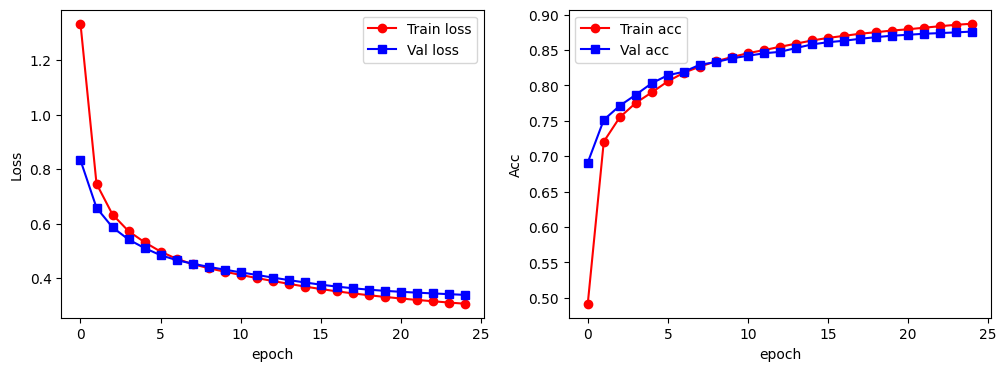

In [ ]:
# Visualize the training process
plt.figure(figsize = (12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_process.epoch, train_process.train_loss_all, 'ro-', label = 'Train loss')
plt.plot(train_process.epoch, train_process.val_loss_all, 'bs-', label = 'Val loss')
plt.legend()
plt.xlabel('epoch')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
plt.plot(train_process.epoch, train_process.train_acc_all, 'ro-', label = 'Train acc')
plt.plot(train_process.epoch, train_process.val_acc_all, 'bs-', label = 'Val acc')
plt.legend()
plt.xlabel('epoch')
plt.ylabel('Acc')

plt.show()

In [ ]:
# Test set predictions and visualize predictions
mylenet.eval()
output = mylenet(test_data_x.to(device))
pre_lab = torch.argmax(output, 1)
acc = accuracy_score(test_data_y, pre_lab.cpu())
print(test_data_y)
print(pre_lab)
print('The prediction accuracy on the test set is', acc)

tensor([9, 2, 1,  ..., 8, 1, 5])
tensor([9, 2, 1,  ..., 8, 1, 5], device='cuda:0')
测试集上的预测精度为 0.8697


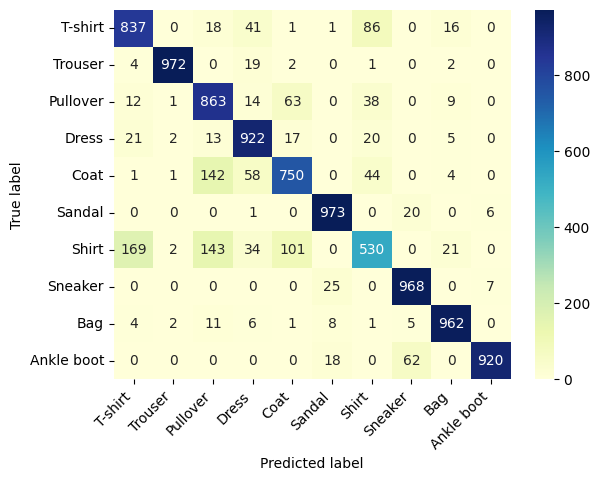

In [ ]:
# Calculate and visualize the confusion matrix on the test set
conf_mat = confusion_matrix(test_data_y, pre_lab.cpu())
df_cm = pd.DataFrame(conf_mat, index = label, columns = label)
heatmap = sns.heatmap(df_cm, annot = True, fmt = 'd', cmap = 'YlGnBu')
heatmap.yaxis.set_ticklabels(heatmap.yaxis.get_ticklabels(), rotation = 0, ha = 'right')
heatmap.xaxis.set_ticklabels(heatmap.xaxis.get_ticklabels(), rotation = 45, ha = 'right')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()